In [2]:
import os
import sys
import random
from pathlib import Path
from importlib import reload

import numpy as np
import pandas as pd
import torch
from sklearn.metrics import roc_auc_score

# Seeds
SEED = 58
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Add parent directory to path for imports (notebook context doesn't have __file__)
sys.path.insert(0, os.path.abspath(".."))
for mod in list(sys.modules.keys()):
    if "base" in mod or "data_loader" in mod or "ModelWrapper" in mod or "benchmark" in mod:
        del sys.modules[mod]

# Auto-configure paths from centralized config
from benchmark_config import (
    PROJECT_ROOT, SRC_ROOT, ADBENCH_ROOT, ADBENCH_DATASETS,
    DATASET_CONFIG, TEST_SCENARIOS, EVAL_DATASETS,
    get_scenario, get_model_config
)

# Ensure paths are in sys.path
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))
if str(ADBENCH_ROOT) not in sys.path:
    sys.path.append(str(ADBENCH_ROOT))

from utils import create_models, validate_data

import base
base = reload(base)
from base import Model, Data, CoLearning
from colearner import SimpleCoLearner, SingleModel, CoLearnerVal
from strategy import SimpleStrategy, PlateauStrategy, AdaptivePlateauStrategy, RecurrentPlateauStrategy
import baselines.adbench.ModelWrapperADBench as mw
mw = reload(mw)
from baselines.adbench.ModelWrapperADBench import PYOD_AVAILABLE
from baselines.adbench.data_loader import ClassicalADBenchData, load_data

# Data loading configuration
TRAIN_SPLIT = 0.60
VAL_TEST_SPLIT = 0.50
SEMI_LABEL_RATIO = 0.10
SEMI_STRATIFIED = True
PRESERVE_LABELED = True

print(f"Paths: root={PROJECT_ROOT.name}, data={ADBENCH_DATASETS}")
print(f"Config: train={TRAIN_SPLIT} val_test={VAL_TEST_SPLIT} semi={SEMI_LABEL_RATIO} strat={SEMI_STRATIFIED} preserve={PRESERVE_LABELED}")

2026-02-20 16:05:02.764760: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-20 16:05:02.939182: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-20 16:05:02.939206: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-20 16:05:02.939680: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-20 16:05:03.017038: I tensorflow/core/platform/cpu_feature_g

Paths: root=CoBench, data=/home/peppino58/CoBench/SubModules/ADBench/adbench/datasets/Classical
Config: train=0.6 val_test=0.5 semi=0.1 strat=True preserve=True


pip uninstall scikit-learn pyod -y
pip install --no-cache-dir scikit-learn==1.0.2
pip install --no-cache-dir pyod==1.0.9

In [3]:
# Use centralized path configuration
DATASET_PATH = DATASET_CONFIG["path"]

data = ClassicalADBenchData(
    DATASET_PATH,
    train_test_split_ratio=TRAIN_SPLIT,
    val_test_split_ratio=VAL_TEST_SPLIT,
    preserve_labeled=PRESERVE_LABELED,
    labeled_ratio=SEMI_LABEL_RATIO,
    stratified=SEMI_STRATIFIED)

# Benchmark integrity checks
validate_data(data)

labels = data.semisupervised_labels
n_real = int(np.sum(labels != -1))
n_false = int(np.sum(labels == -1))

print(f"Data: train={data.n_train} val={data.n_val} test={data.n_test} d={data.X_train.shape[1]} at {DATASET_PATH}")
print(f"original labels: among {data.n_train} really labeled ={int(np.sum(labels!=-1))} unlabeled (-1) = {int(np.sum(labels==-1))}")
print(f"unlabeled_policy: {data.unlabeled_policy}")

Data: train=4320 val=1440 test=1440 d=6 at /home/peppino58/CoBench/SubModules/ADBench/adbench/datasets/Classical/2_annthyroid.npz
original labels: among 4320 really labeled =432 unlabeled (-1) = 3888
unlabeled_policy: unlabeled_as_normal


In [4]:
model_to_test = "prenet"
model_names = ["prenet", "deepsad"]
recurrent_model = ["gru"] #TODO flexible way of changing the recurrent model 

In [5]:
#TEST 1 : solo model train, quick check to see if it learns, if the loss (if available) gets minimized
#TODO, iterate on the models in model_names instead of only moddel_to_test 
registry = mw.get_model_detector_dict()
results_summary = {}

prenet_cls = registry[model_to_test]
print(f"Model: {prenet_cls.__name__}")

train_config = {"total_epochs": 2, "batch_size": 256}
prenet = prenet_cls(train_config=train_config, model_config={}, data=data)

for epoch in range(5):
    prenet.train(1)
    scores = prenet.predict_scores()
    auc_score = roc_auc_score(data.y_test, scores)
    loss = None
    if hasattr(prenet, "get_loss"):
        try:
            loss = prenet.get_loss()
        except TypeError:
            loss = None
    loss_str = f" loss={loss:.4f}" if loss is not None else ""
    print(f"epoch {epoch} auc={auc_score:.4f}{loss_str}")

results_summary[model_to_test] = auc_score
print(f"Summary: {model_to_test} auc={auc_score:.4f}")

Model: PReNetWrapper
epoch 0 auc=0.5818 loss=0.9975
epoch 1 auc=0.6772 loss=0.9860
epoch 2 auc=0.7199 loss=0.9739
epoch 3 auc=0.7431 loss=0.9599
epoch 4 auc=0.7550 loss=0.9455
Summary: prenet auc=0.7550


In [7]:
#TEST 2 : check if co-learning and its strategy work, 
registry = mw.get_model_detector_dict()

CoLearnerClass = CoLearnerVal

data_test1 = ClassicalADBenchData(
    DATASET_PATH,
    train_test_split_ratio=TRAIN_SPLIT,
    val_test_split_ratio=VAL_TEST_SPLIT,
    preserve_labeled=PRESERVE_LABELED,
    labeled_ratio=SEMI_LABEL_RATIO,
    stratified=SEMI_STRATIFIED
)

print(f"TEST1 solo vs {CoLearnerClass.__name__}: {model_names}")

models = create_models(registry, model_names, data_test1)
solo_results = {}

for i, model in enumerate(models):
    model.fit()
    scores = model.predict_scores()
    auc = roc_auc_score(data_test1.y_test, scores)
    solo_results[f"model_{i}"] = auc

print("Solo AUCs: " + ", ".join([f"{k}={v:.4f}" for k, v in solo_results.items()]))

strategy = PlateauStrategy(metric_key="ensemble", mode="max", patience=5, min_delta=0.001)
colearner = CoLearnerClass(
    models=models,
    data=data_test1,
    strategy=strategy,
    warmup_epochs=1,
    max_chapters=3,
    anomaly_threshold=0.5,
    confidence_threshold_low=0.05,
    confidence_threshold_high=0.95,
 )
history = colearner.cotrain(eval_interval=1)

collab_metrics = {}
for i, model in enumerate(models):
    test_scores = model.predict_scores()
    collab_metrics[f"model_{i}"] = roc_auc_score(data_test1.y_test, test_scores)
ensemble_scores = np.mean([model.predict_scores() for model in models], axis=0)
collab_metrics["ensemble"] = roc_auc_score(data_test1.y_test, ensemble_scores)

for key, value in collab_metrics.items():
    solo_val = solo_results.get(key, 0.0)
    delta = value - solo_val
    print(f"{key}: solo={solo_val:.4f} collab={value:.4f} delta={delta:+.4f}")

TEST1 solo vs CoLearnerVal: ['prenet', 'deepsad']
Solo AUCs: model_0=0.8393, model_1=0.9460
model_0: solo=0.8393 collab=0.8468 delta=+0.0076
model_1: solo=0.9460 collab=0.9535 delta=+0.0075
ensemble: solo=0.0000 collab=0.9261 delta=+0.9261


In [8]:
print("TEST3 pseudo-labels")
print(f"original labels: among {data.n_train} | anomalies = {int(np.sum(labels==1))} | normals = {int(np.sum(labels==0))} | unlabeled (-1) = {int(np.sum(labels==-1))}")
for model_idx, model in enumerate(models):
    pseudo_labels = model._pseudo_labels
    n_pseudo, n_normal, n_anomaly = np.sum(pseudo_labels != -1), np.sum(pseudo_labels == 0),np.sum(pseudo_labels == 1)
    print(f"{model.__class__.__name__}: total={n_pseudo} normal={n_normal} anomaly={n_anomaly} | proportion = {round(100*(n_normal+n_anomaly)/int(np.sum(labels==-1)),4)}%")

TEST3 pseudo-labels
original labels: among 4320 | anomalies = 32 | normals = 400 | unlabeled (-1) = 3888
PReNetWrapper: total=3473 normal=3472 anomaly=1 | proportion = 89.3261%
DeepSADWrapper: total=1 normal=0 anomaly=1 | proportion = 0.0257%


We then test with the judge model

In [9]:
# GRU Recurrent Ensemble Test
from importlib import reload

import colearner as colearner_mod
import recurrentmodels as recurrentmodels_mod
colearner_mod = reload(colearner_mod)
recurrentmodels_mod = reload(recurrentmodels_mod)
from colearner import DelayedRecurrentCoLearner
from recurrentmodels import GRURecurrentModel
from strategy import RecurrentPlateauStrategy
from utils import extract_embeddings_auto

registry = mw.get_model_detector_dict()

model_names_gru = ["prenet", "deepsad"]
data_gru = ClassicalADBenchData(
    DATASET_PATH,
    train_test_split_ratio=TRAIN_SPLIT,
    val_test_split_ratio=VAL_TEST_SPLIT,
    preserve_labeled=PRESERVE_LABELED,
    labeled_ratio=SEMI_LABEL_RATIO,
    stratified=SEMI_STRATIFIED,
 )

models_gru = create_models(registry, model_names_gru, data_gru)
gru_model = GRURecurrentModel(
    hidden_size=128,
    num_layers=1,
    dropout=0.0,
    lr=1e-3,
    batch_size=256,
    num_epochs=5,
    seed=SEED,
    n_detectors=len(models_gru),
 )

# GRU-aware strategy: monitors detector ensemble before GRU starts,
# then switches to monitoring GRU AUC once the judge model is active
strategy_gru = RecurrentPlateauStrategy(
    recurrent_start_chapter=3,
    fallback_key="ensemble",
    recurrent_key="gru",
    mode="max",
    patience_fallback=5,
    patience_recurrent=3,
    min_delta=0.001,
)

colearner_gru = DelayedRecurrentCoLearner(
    models=models_gru,
    data=data_gru,
    strategy=strategy_gru,
    recurrent_model=gru_model,
    warmup_epochs=10,
    max_chapters=10,
    embeddings_aggregate="stack",
    recurrent_start_chapter=3,
 )

# Build validation embeddings and attach to GRU for val-loss tracking
if data_gru.X_val is not None and data_gru.y_val is not None:
    val_embeddings = []
    for m in models_gru:
        x_test_orig = getattr(m, "X_test", None)
        y_test_orig = getattr(m, "y_test", None)
        m.X_test, m.y_test = m.X_val, data_gru.y_val
        try:
            emb = extract_embeddings_auto(
                m,
                indexes=None,
                use_train=False,
                layer=colearner_gru.embeddings_layer,
                batch_size=colearner_gru.embeddings_batch_size,
            )
        finally:
            m.X_test, m.y_test = x_test_orig, y_test_orig

        emb = np.asarray(emb)
        if emb.ndim == 1:
            emb = emb.reshape(-1, 1)
        val_embeddings.append(emb)

    max_dim = max(emb.shape[1] for emb in val_embeddings)
    val_padded = []
    for emb in val_embeddings:
        if emb.shape[1] < max_dim:
            pad = np.zeros((emb.shape[0], max_dim - emb.shape[1]), dtype=emb.dtype)
            emb = np.concatenate([emb, pad], axis=1)
        val_padded.append(emb)

    val_agg = np.stack(val_padded, axis=1)
    gru_model.set_validation_data(val_agg, data_gru.y_val)

history_gru = colearner_gru.cotrain(eval_interval=1)

colearner_gru.embeddings_use_train = False
test_embeddings = colearner_gru._collect_embeddings(indexes=None)
gru_scores = gru_model.predict_scores(test_embeddings)
gru_auc = roc_auc_score(data_gru.y_test, gru_scores)
print(f"GRU Recurrent Model Test AUC on {data_test1}: {gru_auc:.4f}")

GRU Recurrent Model Test AUC on ClassicalADBenchData(dataset=2_annthyroid.npz, n_train=4320, n_test=1440, n_val=1440, n_features=6): 0.9202


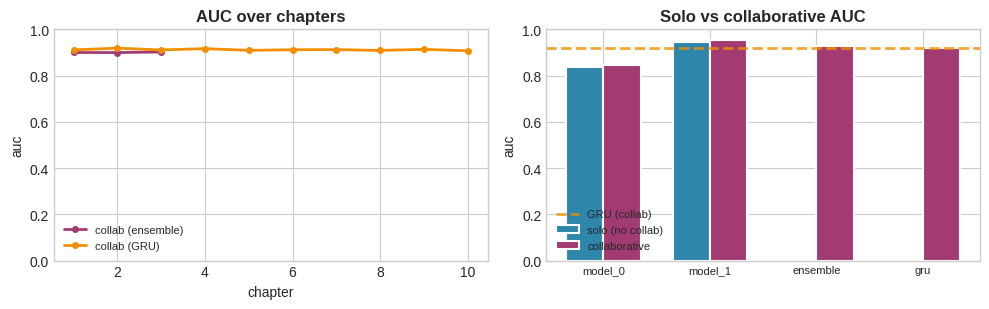

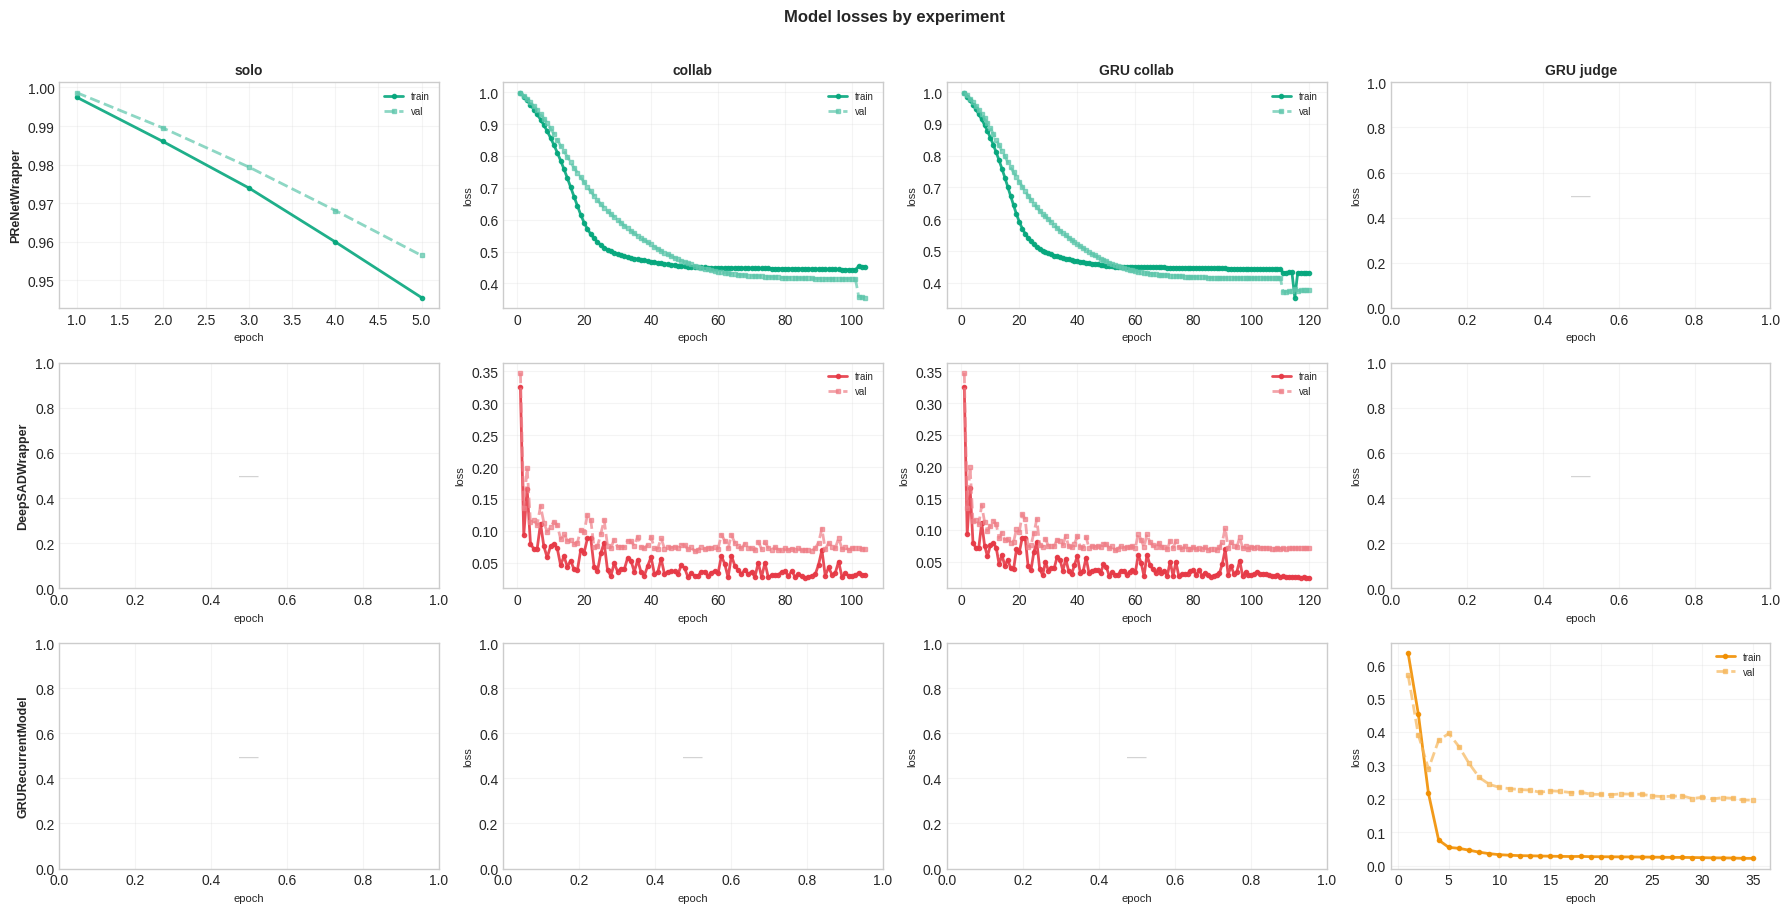

In [12]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from collections import defaultdict, OrderedDict
%matplotlib inline

plt.style.use("seaborn-v0_8-whitegrid")

COLORS = {
    "solo": "#2E86AB",
    "collab": "#A23B72",
    "gru": "#F18F01",
    "prenet": "#06A77D",
    "deepsad": "#E63946",
    "ensemble": "#8338EC",
}

def _lighten_color(color, amount=0.35):
    """Lighten a color by mixing with white."""
    c = np.array(mcolors.to_rgb(color))
    return tuple(c + (1 - c) * amount)

def _plot_auc(histories, labels, ax, title):
    colors_map = ["#A23B72", "#F18F01"]
    for i, (hist, label) in enumerate(zip(histories, labels)):
        if not hist or "chapters" not in hist or not hist["chapters"]:
            continue
        chapters = hist["chapters"]
        x = np.arange(1, len(chapters) + 1)
        y = [c.get("ensemble", np.nan) for c in chapters]
        ax.plot(x, y, marker="o", linewidth=2, markersize=4, label=label, color=colors_map[i])
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("chapter"); ax.set_ylabel("auc"); ax.set_ylim(0.0, 1.0)
    ax.legend(fontsize=8)

def _plot_solo_vs_collab(solo, collab, gru_val, ax, title):
    if not solo or not collab:
        return
    keys = [k for k in collab.keys() if k in solo]
    if "ensemble" in collab:
        keys.append("ensemble")
    labels = keys + (["gru"] if gru_val is not None else [])
    solo_vals = [solo.get(k, np.nan) for k in keys] + ([np.nan] if gru_val is not None else [])
    collab_vals = [collab.get(k, np.nan) for k in keys] + ([gru_val] if gru_val is not None else [])
    x = np.arange(len(labels)); w = 0.35
    ax.bar(x - w/2, solo_vals, width=w, label="solo (no collab)", color=COLORS["solo"], edgecolor="white", linewidth=1.5)
    ax.bar(x + w/2, collab_vals, width=w, label="collaborative", color=COLORS["collab"], edgecolor="white", linewidth=1.5)
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8)
    ax.set_title(title, fontweight="bold"); ax.set_ylabel("auc"); ax.set_ylim(0.0, 1.0)
    if gru_val is not None and not np.isnan(gru_val):
        ax.axhline(y=gru_val, color=COLORS["gru"], linestyle="--", linewidth=2, label="GRU (collab)", alpha=0.8)
    ax.legend(fontsize=8, loc="best")

# ── AUC overview ──
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
_plot_auc([history, history_gru], ["collab (ensemble)", "collab (GRU)"], axes[0], "AUC over chapters")
_plot_solo_vs_collab(solo_results, collab_metrics, gru_auc if 'gru_auc' in globals() else None, axes[1], "Solo vs collaborative AUC")
fig.tight_layout(); plt.show()

# ── Loss mosaic: rows = model type, cols = experiment ──
color_map = {
    "PReNetWrapper": COLORS["prenet"],
    "DeepSADWrapper": COLORS["deepsad"],
    "GRURecurrentModel": COLORS["gru"],
}
experiments = OrderedDict([
    ("solo", [prenet]),
    ("collab", models if 'models' in globals() else []),
    ("GRU collab", models_gru if 'models_gru' in globals() else []),
])
# Build grid[model_type][experiment] = model
grid = OrderedDict()
for exp, ms in experiments.items():
    ms = ms if isinstance(ms, list) else [ms]
    for m in ms:
        name = m.__class__.__name__
        grid.setdefault(name, OrderedDict())[exp] = m
# Append GRU judge as its own row
grid["GRURecurrentModel"] = {"GRU judge": gru_model}

row_names = list(grid.keys())
col_set = []
for row_data in grid.values():
    for c in row_data:
        if c not in col_set:
            col_set.append(c)

nrows = len(row_names)
ncols = len(col_set)
fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 3 * nrows), squeeze=False)

for r, model_type in enumerate(row_names):
    row_data = grid[model_type]
    color = color_map.get(model_type, "#555555")
    for c, exp in enumerate(col_set):
        ax = axes[r][c]
        m = row_data.get(exp)
        has = False
        if m is not None:
            train = getattr(m, "_train_loss_history", None)
            val = getattr(m, "_val_loss_history", None)
            if train:
                ax.plot(np.arange(1, len(train)+1), train, marker="o", linewidth=2,
                        markersize=3, color=color, label="train", alpha=0.9)
                has = True
            if val:
                val_c = _lighten_color(color, 0.35)
                ax.plot(np.arange(1, len(val)+1), val, marker="s", linewidth=2,
                        markersize=3, color=val_c, linestyle="--", label="val", alpha=0.7)
                has = True
            if not has:
                last = getattr(m, "_last_loss", None)
                if last is not None:
                    ax.plot([1], [last], marker="o", markersize=6, color=color, label="last loss")
                    has = True
        if has:
            ax.legend(fontsize=7, loc="best")
        else:
            ax.text(0.5, 0.5, "—", ha="center", va="center", transform=ax.transAxes, fontsize=14, color="lightgray")
        ax.set_xlabel("epoch", fontsize=8); ax.set_ylabel("loss", fontsize=8)
        ax.grid(True, alpha=0.2)
        # Row / col headers
        if c == 0:
            ax.set_ylabel(model_type, fontsize=9, fontweight="bold")
        if r == 0:
            ax.set_title(exp, fontweight="bold", fontsize=10)

fig.suptitle("Model losses by experiment", fontweight="bold", fontsize=12, y=1.01)
fig.tight_layout()
plt.show()

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# CROSS-VALIDATION BENCHMARK  –  N trials, different random seeds
# Evaluates: solo baselines · collaborative (CoLearnerVal) · GRU judge
# Stores: AUC, AP, loss histories, per-chapter AUCs → ready for plotting
# ══════════════════════════════════════════════════════════════════════

from sklearn.metrics import roc_auc_score, average_precision_score
from utils import extract_embeddings_auto
import time

N_TRIALS       = 10
CV_WARMUP      = 20
CV_MAX_CHAP    = 15
CV_EP_PER_CHAP = 3
CV_GRU_START   = 3

registry = mw.get_model_detector_dict()

# ── Result storage (lists indexed by trial) ──
cv_results = {
    "n_trials": N_TRIALS,
    "dataset": str(DATASET_PATH),
    "model_names": list(model_names),
    "seeds": [],
    # Solo baselines: per model name
    "solo": {n: {"auc": [], "ap": [], "train_loss": [], "val_loss": []}
             for n in model_names},
    # Collaborative: per model name + "ensemble"
    "collab": {n: {"auc": [], "ap": [], "train_loss": [], "val_loss": []}
               for n in list(model_names) + ["ensemble"]},
    "collab_chapters": [],          # list[trial] of cotrain history dicts
    "collab_val_loss": [],          # list[trial] of {model_idx: [loss_per_epoch]}
    # GRU recurrent judge
    "gru": {"auc": [], "ap": [], "train_loss": [], "val_loss": [],
            "chapters": []},        # list[trial] of gru cotrain history
}

t_total = time.time()

for trial in range(N_TRIALS):
    seed = SEED + trial
    cv_results["seeds"].append(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    t0 = time.time()
    print(f"\n{'='*60}\n  Trial {trial+1}/{N_TRIALS}  (seed={seed})\n{'='*60}")

    # Same data split for solo / collab / GRU within a trial (fair comparison)
    trial_data = ClassicalADBenchData(
        DATASET_PATH,
        train_test_split_ratio=TRAIN_SPLIT,
        val_test_split_ratio=VAL_TEST_SPLIT,
        preserve_labeled=PRESERVE_LABELED,
        labeled_ratio=SEMI_LABEL_RATIO,
        stratified=SEMI_STRATIFIED,
        random_state=seed,
    )

    # ── 1. SOLO BASELINES ──────────────────────────────────────────
    solo_models = create_models(registry, model_names, trial_data)
    for name, m in zip(model_names, solo_models):
        m.fit()
        sc = m.predict_scores()
        auc = roc_auc_score(trial_data.y_test, sc)
        ap  = average_precision_score(trial_data.y_test, sc)
        cv_results["solo"][name]["auc"].append(auc)
        cv_results["solo"][name]["ap"].append(ap)
        cv_results["solo"][name]["train_loss"].append(
            getattr(m, "_train_loss_history", []).copy())
        cv_results["solo"][name]["val_loss"].append(
            getattr(m, "_val_loss_history", []).copy())
        print(f"  Solo {name:<12} AUC={auc:.4f}  AP={ap:.4f}")

    # ── 2. COLLABORATIVE (CoLearnerVal on validation) ──────────────
    collab_models = create_models(registry, model_names, trial_data)
    strat_cv = PlateauStrategy(
        metric_key="ensemble", mode="max", patience=5, min_delta=0.001)
    cl = CoLearnerVal(
        models=collab_models, data=trial_data, strategy=strat_cv,
        warmup_epochs=CV_WARMUP, max_chapters=CV_MAX_CHAP,
        epochs_per_chapter=CV_EP_PER_CHAP,
        anomaly_threshold=0.5,
        confidence_threshold_low=0.05,
        confidence_threshold_high=0.95,
    )
    hist_cv = cl.cotrain(eval_interval=1)
    cv_results["collab_chapters"].append(hist_cv)
    cv_results["collab_val_loss"].append(
        {i: list(v) for i, v in cl.val_loss_history.items()})

    for name, m in zip(model_names, collab_models):
        sc  = m.predict_scores()
        auc = roc_auc_score(trial_data.y_test, sc)
        ap  = average_precision_score(trial_data.y_test, sc)
        cv_results["collab"][name]["auc"].append(auc)
        cv_results["collab"][name]["ap"].append(ap)
        cv_results["collab"][name]["train_loss"].append(
            getattr(m, "_train_loss_history", []).copy())
        cv_results["collab"][name]["val_loss"].append(
            getattr(m, "_val_loss_history", []).copy())
        print(f"  Collab {name:<10} AUC={auc:.4f}  AP={ap:.4f}")

    ens_sc  = np.mean([m.predict_scores() for m in collab_models], axis=0)
    ens_auc = roc_auc_score(trial_data.y_test, ens_sc)
    ens_ap  = average_precision_score(trial_data.y_test, ens_sc)
    cv_results["collab"]["ensemble"]["auc"].append(ens_auc)
    cv_results["collab"]["ensemble"]["ap"].append(ens_ap)
    print(f"  Collab ensemble   AUC={ens_auc:.4f}  AP={ens_ap:.4f}")

    # ── 3. GRU RECURRENT JUDGE ─────────────────────────────────────
    try:
        gru_models = create_models(registry, model_names, trial_data)
        gru_m = GRURecurrentModel(
            hidden_size=128, num_layers=1, dropout=0.0, lr=1e-3,
            batch_size=256, num_epochs=5, seed=seed,
            n_detectors=len(gru_models),
        )
        gru_strat = RecurrentPlateauStrategy(
            recurrent_start_chapter=CV_GRU_START, fallback_key="ensemble",
            recurrent_key="gru", mode="max",
            patience_fallback=5, patience_recurrent=3, min_delta=0.001,
        )
        gru_cl = DelayedRecurrentCoLearner(
            models=gru_models, data=trial_data, strategy=gru_strat,
            recurrent_model=gru_m, warmup_epochs=CV_WARMUP,
            max_chapters=CV_MAX_CHAP, embeddings_aggregate="stack",
            recurrent_start_chapter=CV_GRU_START,
        )

        # Attach validation embeddings for GRU val-loss tracking
        if trial_data.X_val is not None and trial_data.y_val is not None:
            val_embs = []
            for m in gru_models:
                x_bak, y_bak = m.X_test, m.y_test
                m.X_test, m.y_test = m.X_val, trial_data.y_val
                try:
                    emb = extract_embeddings_auto(
                        m, indexes=None, use_train=False,
                        layer=gru_cl.embeddings_layer,
                        batch_size=gru_cl.embeddings_batch_size)
                finally:
                    m.X_test, m.y_test = x_bak, y_bak
                emb = np.asarray(emb)
                if emb.ndim == 1:
                    emb = emb.reshape(-1, 1)
                val_embs.append(emb)
            mx = max(e.shape[1] for e in val_embs)
            padded = [
                np.concatenate([e, np.zeros((e.shape[0], mx - e.shape[1]),
                               dtype=e.dtype)], axis=1)
                if e.shape[1] < mx else e for e in val_embs
            ]
            gru_m.set_validation_data(np.stack(padded, axis=1), trial_data.y_val)

        hist_gru = gru_cl.cotrain(eval_interval=1)

        # Final GRU test evaluation
        gru_cl.embeddings_use_train = False
        test_emb = gru_cl._collect_embeddings(indexes=None)
        gru_sc = gru_m.predict_scores(test_emb)
        g_auc = roc_auc_score(trial_data.y_test, gru_sc)
        g_ap  = average_precision_score(trial_data.y_test, gru_sc)
        cv_results["gru"]["auc"].append(g_auc)
        cv_results["gru"]["ap"].append(g_ap)
        cv_results["gru"]["train_loss"].append(
            getattr(gru_m, "_train_loss_history", []).copy())
        cv_results["gru"]["val_loss"].append(
            getattr(gru_m, "_val_loss_history", []).copy())
        cv_results["gru"]["chapters"].append(hist_gru)
        print(f"  GRU judge      AUC={g_auc:.4f}  AP={g_ap:.4f}")
    except Exception as exc:
        print(f"  ⚠ GRU FAILED: {exc}")
        cv_results["gru"]["auc"].append(np.nan)
        cv_results["gru"]["ap"].append(np.nan)
        cv_results["gru"]["train_loss"].append([])
        cv_results["gru"]["val_loss"].append([])
        cv_results["gru"]["chapters"].append({"chapters": []})

    print(f"  ⏱ {time.time() - t0:.1f}s")

# ══════════════════════════════════════════════════════════════════════
# SUMMARY TABLE
# ══════════════════════════════════════════════════════════════════════
print(f"\n{'='*72}")
print(f"  CROSS-VALIDATION SUMMARY  ({N_TRIALS} trials · {DATASET_CONFIG['name']})")
print(f"{'='*72}")
print(f"  {'Method':<26} {'AUC (mean±std)':<22} {'AP (mean±std)':<22}")
print(f"  {'-'*68}")

for name in model_names:
    a = np.array(cv_results["solo"][name]["auc"])
    p = np.array(cv_results["solo"][name]["ap"])
    print(f"  Solo {name:<20} {a.mean():.4f} ± {a.std():.4f}     {p.mean():.4f} ± {p.std():.4f}")
print(f"  {'-'*68}")

for name in list(model_names) + ["ensemble"]:
    a = np.array(cv_results["collab"][name]["auc"])
    p = np.array(cv_results["collab"][name]["ap"])
    tag = f"Collab {name}"
    print(f"  {tag:<26} {a.mean():.4f} ± {a.std():.4f}     {p.mean():.4f} ± {p.std():.4f}")
print(f"  {'-'*68}")

ga = np.array(cv_results["gru"]["auc"])
gp = np.array(cv_results["gru"]["ap"])
print(f"  {'GRU recurrent':<26} {np.nanmean(ga):.4f} ± {np.nanstd(ga):.4f}     {np.nanmean(gp):.4f} ± {np.nanstd(gp):.4f}")

# Deltas (collab - solo)
print(f"\n  {'Δ (collab − solo)':<26} {'ΔAUC':<22} {'ΔAP':<22}")
print(f"  {'-'*68}")
for name in model_names:
    da = np.array(cv_results["collab"][name]["auc"]) - np.array(cv_results["solo"][name]["auc"])
    dp = np.array(cv_results["collab"][name]["ap"])  - np.array(cv_results["solo"][name]["ap"])
    print(f"  {name:<26} {da.mean():+.4f} ± {da.std():.4f}     {dp.mean():+.4f} ± {dp.std():.4f}")

# GRU vs ensemble delta
if not np.all(np.isnan(ga)):
    d_gru_ens_auc = ga - np.array(cv_results["collab"]["ensemble"]["auc"])
    d_gru_ens_ap  = gp - np.array(cv_results["collab"]["ensemble"]["ap"])
    print(f"\n  {'Δ (GRU − ensemble)':<26} {'ΔAUC':<22} {'ΔAP':<22}")
    print(f"  {'-'*68}")
    print(f"  {'GRU judge':<26} {np.nanmean(d_gru_ens_auc):+.4f} ± {np.nanstd(d_gru_ens_auc):.4f}     {np.nanmean(d_gru_ens_ap):+.4f} ± {np.nanstd(d_gru_ens_ap):.4f}")

print(f"\n  Total time: {time.time() - t_total:.1f}s")
print(f"  cv_results dict ready for plotting in next cells")


  Trial 1/10  (seed=58)
  Solo prenet       AUC=0.7165  AP=0.2950
  Solo deepsad      AUC=0.7932  AP=0.4158
  Collab prenet     AUC=0.7540  AP=0.3583
  Collab deepsad    AUC=0.8638  AP=0.6061
  Collab ensemble   AUC=0.7914  AP=0.4782
  GRU judge      AUC=0.8237  AP=0.4911
  ⏱ 118.5s

  Trial 2/10  (seed=59)
  Solo prenet       AUC=0.7544  AP=0.3636
  Solo deepsad      AUC=0.8205  AP=0.3442
  Collab prenet     AUC=0.7865  AP=0.4200
  Collab deepsad    AUC=0.8989  AP=0.6147
  Collab ensemble   AUC=0.8363  AP=0.5404
  GRU judge      AUC=0.8579  AP=0.5490
  ⏱ 111.0s

  Trial 3/10  (seed=60)
  Solo prenet       AUC=0.6746  AP=0.1985
  Solo deepsad      AUC=0.7930  AP=0.2943
  Collab prenet     AUC=0.7160  AP=0.2624
  Collab deepsad    AUC=0.8717  AP=0.4422
  Collab ensemble   AUC=0.7913  AP=0.3679
  GRU judge      AUC=0.7721  AP=0.3951
  ⏱ 114.2s

  Trial 4/10  (seed=61)
  Solo prenet       AUC=0.7363  AP=0.2868
  Solo deepsad      AUC=0.8505  AP=0.4108
  Collab prenet     AUC=0.7843  AP=0

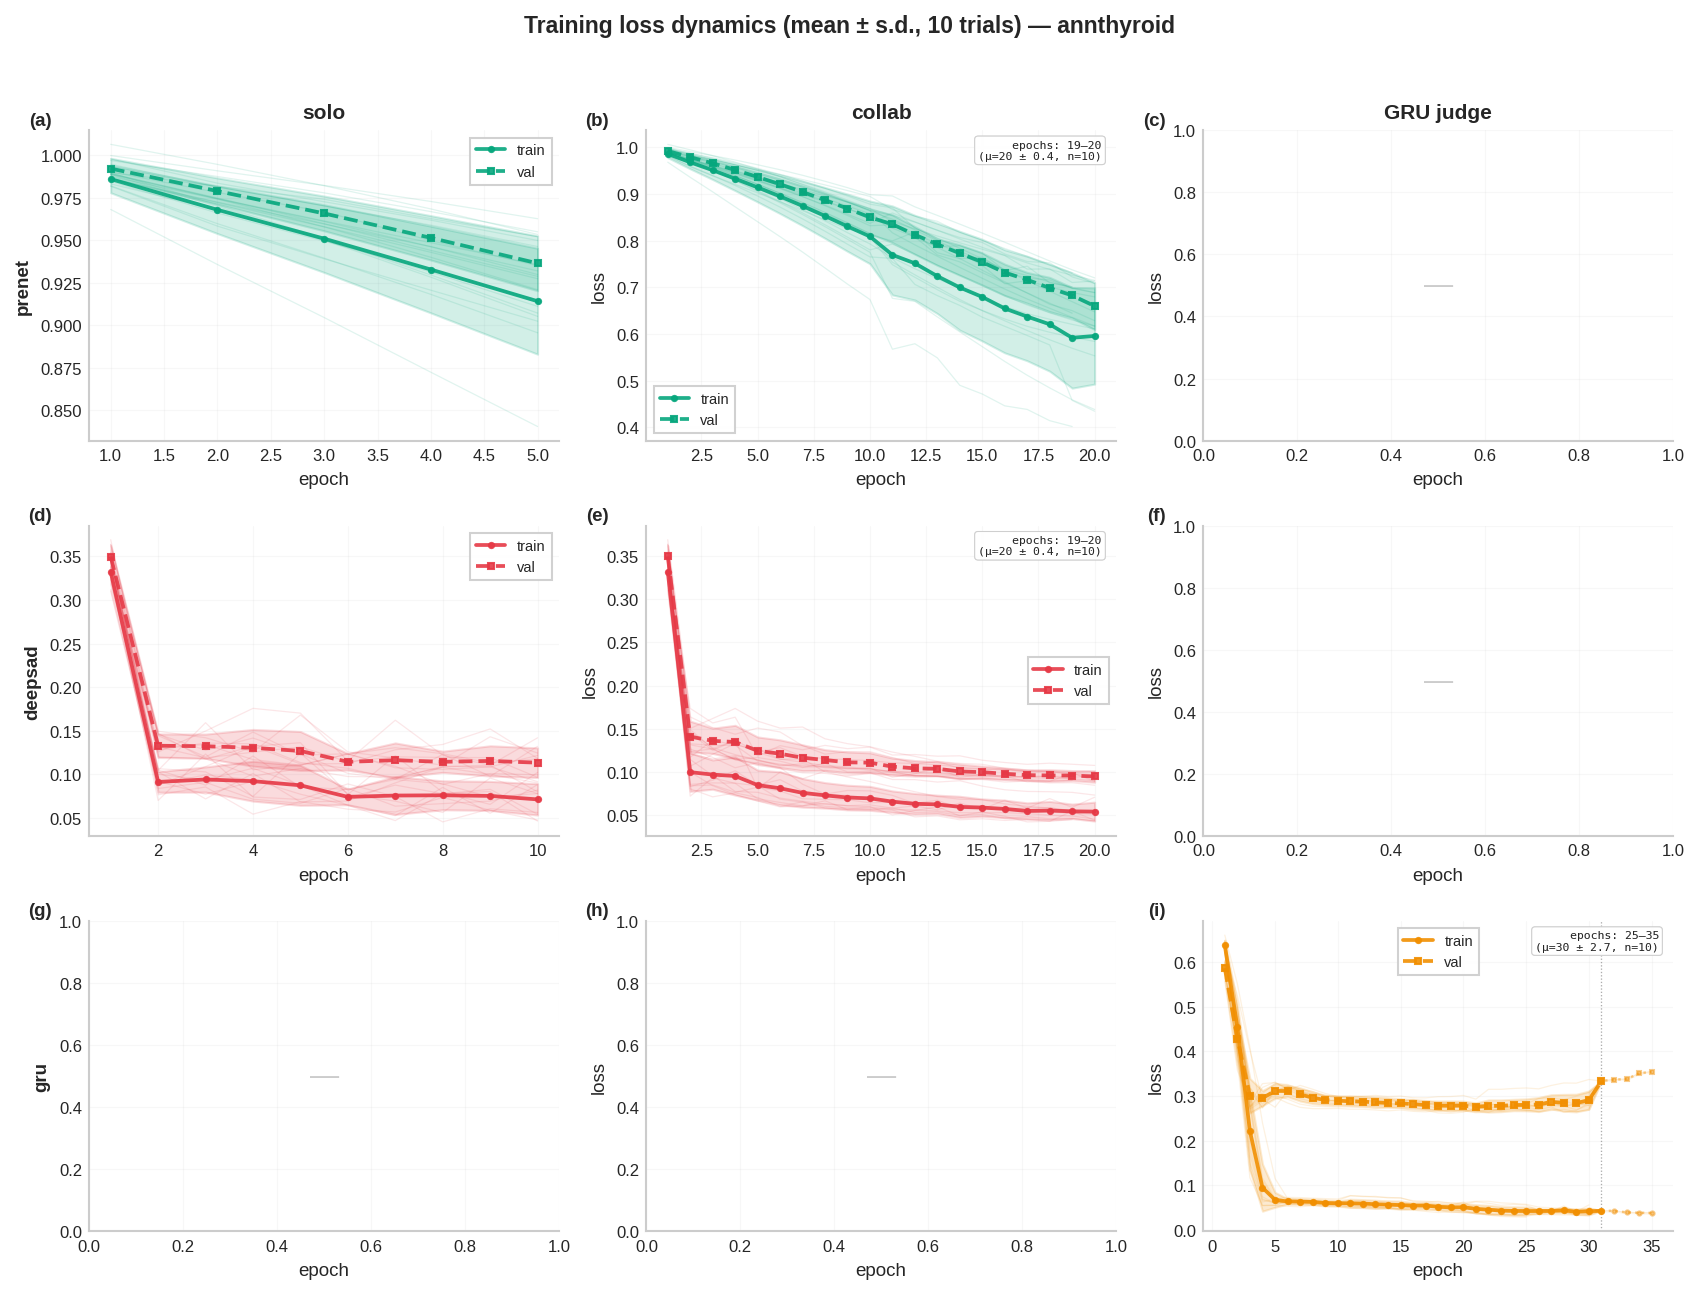

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# CV LOSS PLOT  –  publication-quality mean ± std ribbon
# Features:
#   • NaN-padded aggregation for variable-length histories
#   • Ribbon fades (dashed + reduced alpha) when n_valid < n_trials // 2
#   • Epoch distribution annotation box per subplot
#   • Individual trial traces as thin transparent lines
#   • Validation lines use a lighter shade for visual distinction
# ══════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as mcolors
from collections import OrderedDict
%matplotlib inline

# ── Publication rc overrides (scoped to this cell) ──
_pub_rc = {
    "font.family": "sans-serif",
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 7,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.15,
    "grid.linewidth": 0.5,
}
plt.style.use("seaborn-v0_8-whitegrid")
mpl.rcParams.update(_pub_rc)

# ── Helpers ──
def _lighten_color(color, amount=0.35):
    """Lighten a color by mixing with white."""
    c = np.array(mcolors.to_rgb(color))
    return tuple(c + (1 - c) * amount)

def _pad_and_stack(histories):
    """Stack variable-length lists into a NaN-padded 2-D array (n_trials × max_epochs)."""
    if not histories or all(len(h) == 0 for h in histories):
        return None
    max_len = max(len(h) for h in histories)
    padded = np.full((len(histories), max_len), np.nan)
    for i, h in enumerate(histories):
        padded[i, :len(h)] = h
    return padded

def _plot_loss_ribbon(ax, histories, color, loss_type="train", n_trials_total=None):
    """Plot mean ± std ribbon; fades to dashed when majority of trials have stopped."""
    arr = _pad_and_stack(histories)
    if arr is None:
        return False

    # Use lighter shade for validation so it's distinguishable at high epoch counts
    plot_color = _lighten_color(color, 0.35) if loss_type == "val" else color

    epochs = np.arange(1, arr.shape[1] + 1)
    mean   = np.nanmean(arr, axis=0)
    std    = np.nanstd(arr, axis=0)
    n_valid = np.sum(~np.isnan(arr), axis=0)
    n_tot   = n_trials_total or arr.shape[0]
    threshold = max(2, n_tot // 2)

    ls = "-" if loss_type == "train" else "--"
    mk = "o" if loss_type == "train" else "s"

    # Individual trials (thin, transparent)
    for t in range(arr.shape[0]):
        valid = ~np.isnan(arr[t])
        ax.plot(epochs[valid], arr[t][valid], color=plot_color, alpha=0.12, linewidth=0.6)

    # Split into reliable (n_valid >= threshold) and sparse regions
    reliable_mask = n_valid >= threshold
    sparse_mask   = (~reliable_mask) & (n_valid > 0)

    # Reliable region: solid/dashed line, full ribbon
    if np.any(reliable_mask):
        idx = np.where(reliable_mask)[0]
        # Extend by 1 into sparse region for visual continuity
        end = idx[-1] + 2 if idx[-1] + 1 < len(epochs) else idx[-1] + 1
        sl = slice(0, end)
        ax.plot(epochs[sl], mean[sl], marker=mk, linewidth=1.8, markersize=2.5,
                color=plot_color, linestyle=ls, label=loss_type, alpha=0.9, zorder=3)
        ax.fill_between(epochs[sl], mean[sl] - std[sl], mean[sl] + std[sl],
                        color=plot_color, alpha=0.18)

    # Sparse region: dotted line, faded ribbon
    if np.any(sparse_mask):
        # Include last reliable point for continuity
        first_sparse = np.where(sparse_mask)[0][0]
        start = max(0, first_sparse - 1)
        sl = slice(start, None)
        valid_sl = (n_valid[sl] > 0)
        e_sl = epochs[sl][valid_sl]
        m_sl = mean[sl][valid_sl]
        s_sl = std[sl][valid_sl]
        ax.plot(e_sl, m_sl, linewidth=1.2, markersize=2, marker=mk,
                color=plot_color, linestyle=":", alpha=0.45, zorder=3)
        ax.fill_between(e_sl, m_sl - s_sl, m_sl + s_sl, color=plot_color, alpha=0.07)

        # Transition marker: vertical line where data becomes sparse
        ax.axvline(x=epochs[first_sparse], color="gray", linestyle=":",
                   linewidth=0.6, alpha=0.4)

    # Epoch distribution annotation
    lengths = [len(h) for h in histories if len(h) > 0]
    if lengths and len(set(lengths)) > 1:
        ann = (f"epochs: {min(lengths)}–{max(lengths)}\n"
               f"(μ={np.mean(lengths):.0f} ± {np.std(lengths):.1f}, n={len(lengths)})")
        ax.text(0.97, 0.97, ann, transform=ax.transAxes, fontsize=5.5,
                va="top", ha="right", family="monospace",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                          edgecolor="#cccccc", alpha=0.85, linewidth=0.5))
    return True

# ── Build grid: rows = model, cols = config ──
model_color = {
    "prenet":  COLORS["prenet"],
    "deepsad": COLORS["deepsad"],
    "gru":     COLORS["gru"],
}

configs = OrderedDict()
for name in cv_results["model_names"]:
    configs.setdefault(name, OrderedDict())
    configs[name]["solo"]   = {"train": cv_results["solo"][name]["train_loss"],
                               "val":   cv_results["solo"][name]["val_loss"]}
    configs[name]["collab"] = {"train": cv_results["collab"][name]["train_loss"],
                               "val":   cv_results["collab"][name]["val_loss"]}
configs["gru"] = OrderedDict()
configs["gru"]["GRU judge"] = {"train": cv_results["gru"]["train_loss"],
                                "val":   cv_results["gru"]["val_loss"]}

row_names = list(configs.keys())
col_set = []
for rd in configs.values():
    for c in rd:
        if c not in col_set:
            col_set.append(c)

nrows = len(row_names)
ncols = len(col_set)
fig, axes = plt.subplots(nrows, ncols, figsize=(3.8 * ncols, 2.8 * nrows), squeeze=False)

for r, model_name in enumerate(row_names):
    color = model_color.get(model_name, "#555555")
    for c, cfg_name in enumerate(col_set):
        ax = axes[r][c]
        entry = configs[model_name].get(cfg_name)
        plotted = False
        if entry is not None:
            nt = cv_results["n_trials"]
            t = _plot_loss_ribbon(ax, entry["train"], color, "train", nt)
            v = _plot_loss_ribbon(ax, entry["val"],   color, "val",   nt)
            plotted = t or v
        if plotted:
            ax.legend(loc="best", frameon=True, framealpha=0.9,
                      edgecolor="#cccccc", fancybox=False)
        else:
            ax.text(0.5, 0.5, "—", ha="center", va="center",
                    transform=ax.transAxes, fontsize=14, color="#cccccc")
        ax.set_xlabel("epoch")
        ax.set_ylabel("loss")
        if c == 0:
            ax.set_ylabel(model_name, fontweight="bold")
        if r == 0:
            ax.set_title(cfg_name, fontweight="bold")

        # Panel label (a, b, c, …)
        panel_idx = r * ncols + c
        panel_letter = chr(ord("a") + panel_idx)
        ax.text(-0.08, 1.06, f"({panel_letter})", transform=ax.transAxes,
                fontsize=9, fontweight="bold", va="top", ha="right")

fig.suptitle(
    f"Training loss dynamics (mean ± s.d., {cv_results['n_trials']} trials) — {DATASET_CONFIG['name']}",
    fontweight="bold", fontsize=11, y=1.02)
fig.tight_layout()
plt.show()

/tmp/ipykernel_133703/3408280047.py:50: RuntimeWarning: Mean of empty slice
  mean    = np.nanmean(arr, axis=0)
/home/peppino58/miniconda3/envs/cobench/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


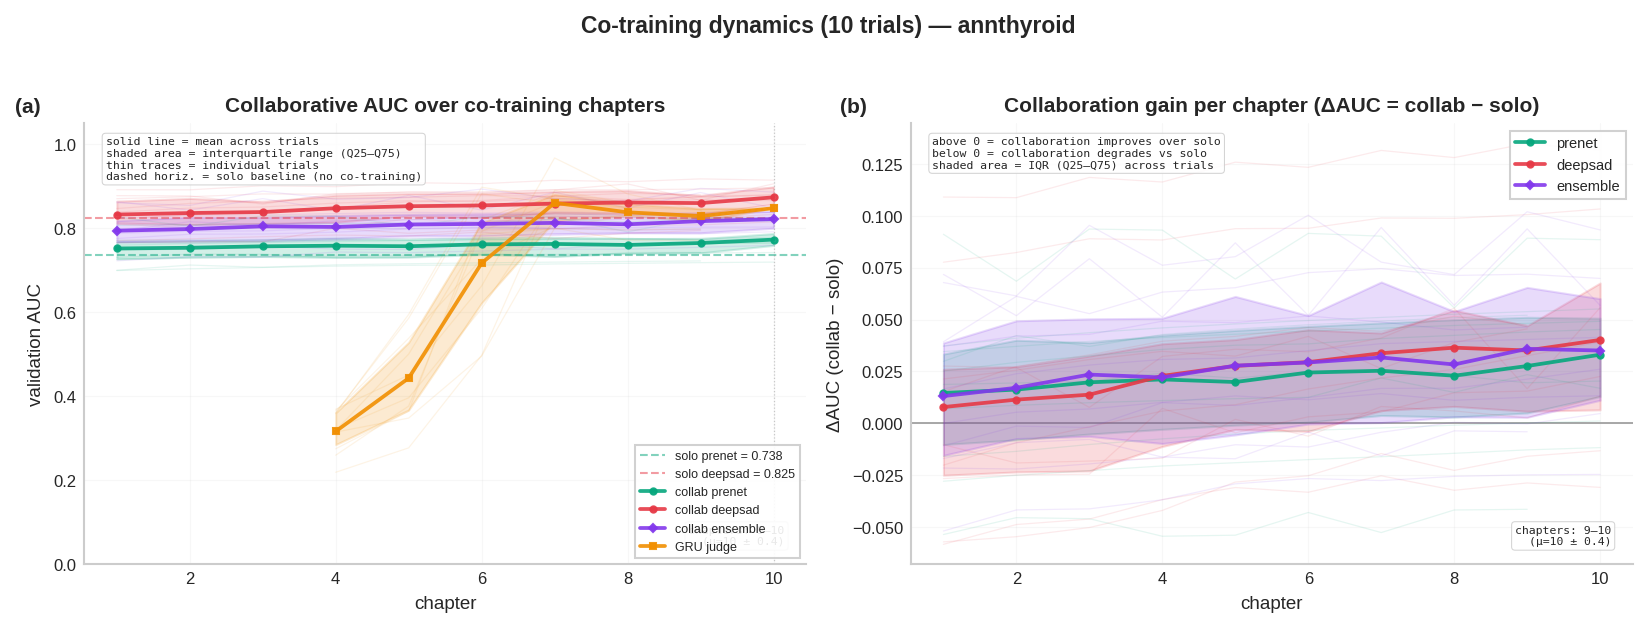

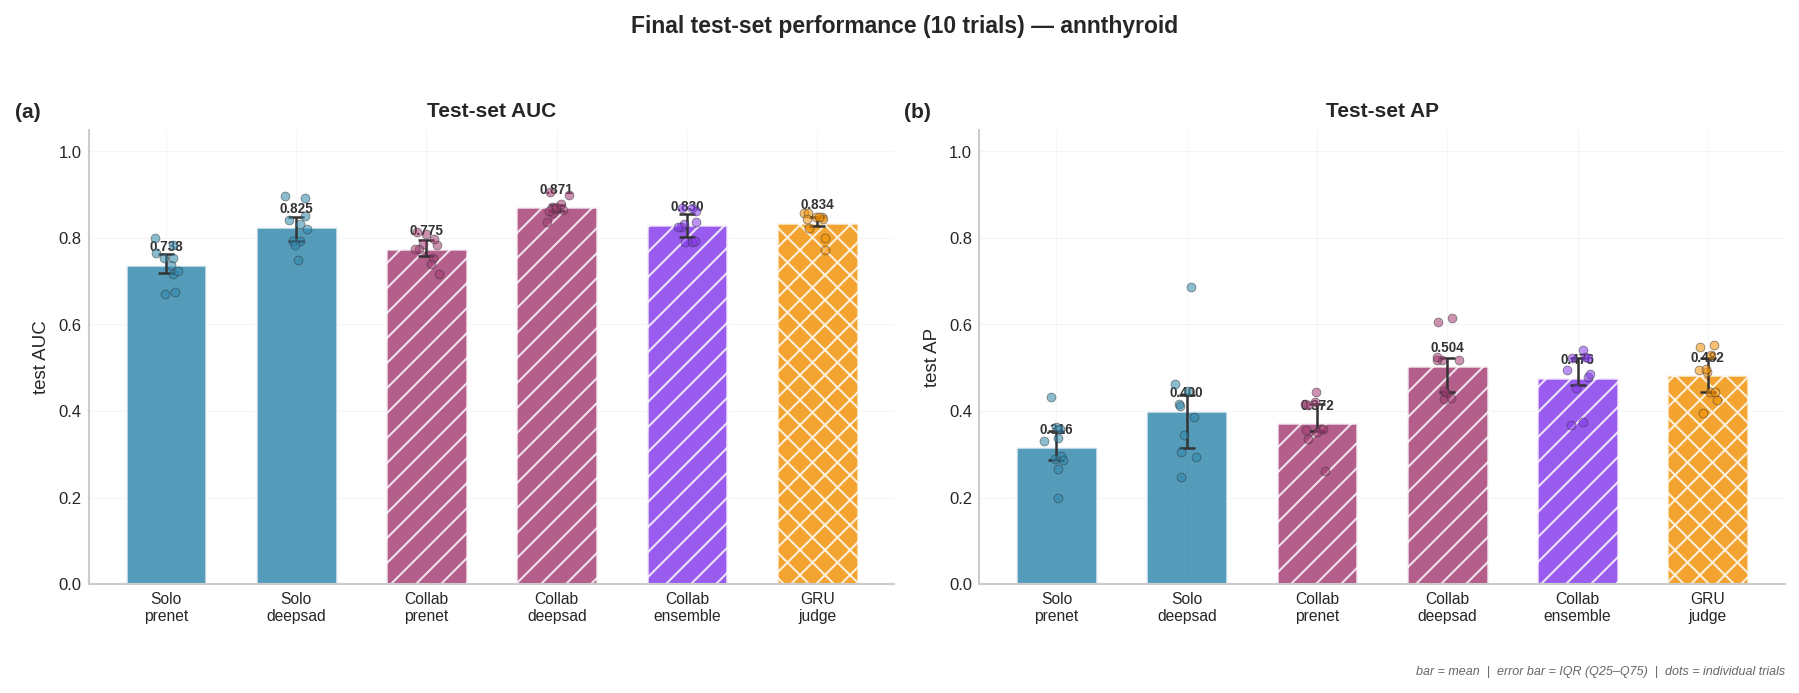

In [22]:
# ══════════════════════════════════════════════════════════════════════
# CV AUC & AP  –  publication-quality chapter dynamics + bar charts
# Figure 1(a): collaborative AUC trajectories (ensemble + GRU + per-model)
#              with solo baselines as dashed horizontal references
# Figure 1(b): ΔAUC = (collab chapter AUC) − (solo AUC) per model
# Figure 2:    final test-set AUC & AP bar charts with IQR + trial scatter
# ══════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib as mpl
from collections import OrderedDict
%matplotlib inline

_pub_rc = {
    "font.family": "sans-serif",
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 7,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.15,
    "grid.linewidth": 0.5,
}
plt.style.use("seaborn-v0_8-whitegrid")
mpl.rcParams.update(_pub_rc)

# ── Helper: extract per-chapter metric across trials, NaN-pad ──
def _chapter_metric_array(chapter_histories, key):
    """Build (n_trials × max_chapters) NaN-padded array for a given metric key."""
    lengths = [len(h.get("chapters", [])) for h in chapter_histories]
    if not lengths or max(lengths) == 0:
        return None
    max_len = max(lengths)
    arr = np.full((len(chapter_histories), max_len), np.nan)
    for t, h in enumerate(chapter_histories):
        for c, chap in enumerate(h.get("chapters", [])):
            arr[t, c] = chap.get(key, np.nan)
    return arr

def _plot_chapter_ribbon(ax, arr, color, label, marker="o", n_trials_total=None):
    """Plot mean + Q25–Q75 ribbon; fades when data becomes sparse."""
    if arr is None or arr.size == 0:
        return
    x       = np.arange(1, arr.shape[1] + 1)
    mean    = np.nanmean(arr, axis=0)
    q25     = np.nanpercentile(arr, 25, axis=0)
    q75     = np.nanpercentile(arr, 75, axis=0)
    n_valid = np.sum(~np.isnan(arr), axis=0)
    n_tot   = n_trials_total or arr.shape[0]
    threshold = max(2, n_tot // 2)

    for t in range(arr.shape[0]):
        valid = ~np.isnan(arr[t])
        ax.plot(x[valid], arr[t][valid], color=color, alpha=0.10, linewidth=0.6)

    reliable_mask = n_valid >= threshold
    sparse_mask   = (~reliable_mask) & (n_valid > 0)

    if np.any(reliable_mask):
        idx = np.where(reliable_mask)[0]
        end = min(idx[-1] + 2, len(x))
        sl = slice(0, end)
        ax.plot(x[sl], mean[sl], marker=marker, linewidth=1.8, markersize=3,
                color=color, label=label, alpha=0.9, zorder=3)
        ax.fill_between(x[sl], q25[sl], q75[sl], color=color, alpha=0.18)

    if np.any(sparse_mask):
        first_sparse = np.where(sparse_mask)[0][0]
        start = max(0, first_sparse - 1)
        sl = slice(start, None)
        v_sl = n_valid[sl] > 0
        ax.plot(x[sl][v_sl], mean[sl][v_sl], marker=marker, linewidth=1.1,
                markersize=2.5, color=color, linestyle=":", alpha=0.4, zorder=3)
        ax.fill_between(x[sl][v_sl], q25[sl][v_sl], q75[sl][v_sl],
                        color=color, alpha=0.06)
        ax.axvline(x=x[first_sparse], color="gray", linestyle=":",
                   linewidth=0.6, alpha=0.4)

    ch_lengths = [int(np.sum(~np.isnan(arr[t]))) for t in range(arr.shape[0])]
    ch_lengths = [l for l in ch_lengths if l > 0]
    if ch_lengths and len(set(ch_lengths)) > 1:
        ann = (f"chapters: {min(ch_lengths)}–{max(ch_lengths)}\n"
               f"(μ={np.mean(ch_lengths):.0f} ± {np.std(ch_lengths):.1f})")
        if not getattr(ax, "_ch_ann_placed", False):
            ax.text(0.97, 0.04, ann, transform=ax.transAxes, fontsize=5.5,
                    va="bottom", ha="right", family="monospace",
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                              edgecolor="#cccccc", alpha=0.85, linewidth=0.5))
            ax._ch_ann_placed = True

# ═══════════════════════════════════════════════════════════════
# Figure 1
# (a) Collaborative training AUC: each model's validation AUC
#     evaluated at every chapter during co-training. Solo baselines
#     (single fit, no chapters) shown as dashed horizontal lines.
# (b) Collaboration gain: ΔAUC = (collab val AUC at chapter c)
#     minus (solo test AUC), per trial per model. Zero = no gain.
# ═══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))
nt = cv_results["n_trials"]

# ── (a) Collab AUC trajectories + solo baselines ──
ax = axes[0]

# Solo = single fit → horizontal reference (mean across trials)
for name in cv_results["model_names"]:
    solo_mean = np.mean(cv_results["solo"][name]["auc"])
    ax.axhline(y=solo_mean, color=COLORS.get(name, "#555"), linestyle="--",
               linewidth=1.0, alpha=0.5,
               label=f"solo {name} = {solo_mean:.3f}")

# Per-model collab AUC at each chapter (ribbon = IQR across trials)
for i, name in enumerate(cv_results["model_names"]):
    arr = _chapter_metric_array(cv_results["collab_chapters"], f"model_{i}")
    _plot_chapter_ribbon(ax, arr, COLORS.get(name, "#555"),
                         f"collab {name}", "o", nt)

# Ensemble AUC ribbon
arr_ens = _chapter_metric_array(cv_results["collab_chapters"], "ensemble")
_plot_chapter_ribbon(ax, arr_ens, COLORS["ensemble"], "collab ensemble", "D", nt)

# GRU judge AUC ribbon
arr_gru = _chapter_metric_array(cv_results["gru"]["chapters"], "gru")
if arr_gru is not None and not np.all(np.isnan(arr_gru)):
    _plot_chapter_ribbon(ax, arr_gru, COLORS["gru"], "GRU judge", "s", nt)

ax.set_title("Collaborative AUC over co-training chapters", fontweight="bold")
ax.set_xlabel("chapter"); ax.set_ylabel("validation AUC"); ax.set_ylim(0.0, 1.05)
ax.legend(loc="lower right", frameon=True, framealpha=0.9,
          edgecolor="#cccccc", fancybox=False, fontsize=6)
ax.text(-0.06, 1.06, "(a)", transform=ax.transAxes,
        fontsize=10, fontweight="bold", va="top", ha="right")

# Annotation box explaining visual encoding
ax.text(0.03, 0.97,
        "solid line = mean across trials\n"
        "shaded area = interquartile range (Q25–Q75)\n"
        "thin traces = individual trials\n"
        "dashed horiz. = solo baseline (no co-training)",
        transform=ax.transAxes, fontsize=5.5, va="top", ha="left",
        family="monospace",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                  edgecolor="#cccccc", alpha=0.85, linewidth=0.5))

# ── (b) Per-model ΔAUC (collab − solo) per chapter ──
ax = axes[1]
ax.axhline(y=0, color="#999999", linewidth=0.8, linestyle="-", zorder=1)

for i, name in enumerate(cv_results["model_names"]):
    arr_model = _chapter_metric_array(cv_results["collab_chapters"], f"model_{i}")
    if arr_model is None:
        continue
    solo_aucs = np.array(cv_results["solo"][name]["auc"])
    delta_arr = arr_model - solo_aucs[:, None]
    _plot_chapter_ribbon(ax, delta_arr, COLORS.get(name, "#555"), name, "o", nt)

arr_ens = _chapter_metric_array(cv_results["collab_chapters"], "ensemble")
if arr_ens is not None:
    solo_avg = np.mean(
        [cv_results["solo"][n]["auc"] for n in cv_results["model_names"]], axis=0)
    delta_ens = arr_ens - solo_avg[:, None]
    _plot_chapter_ribbon(ax, delta_ens, COLORS["ensemble"], "ensemble", "D", nt)

ax.set_title("Collaboration gain per chapter (ΔAUC = collab − solo)", fontweight="bold")
ax.set_xlabel("chapter"); ax.set_ylabel("ΔAUC (collab − solo)")
ax.legend(loc="best", frameon=True, framealpha=0.9,
          edgecolor="#cccccc", fancybox=False)
ax.text(-0.06, 1.06, "(b)", transform=ax.transAxes,
        fontsize=10, fontweight="bold", va="top", ha="right")

ax.text(0.03, 0.97,
        "above 0 = collaboration improves over solo\n"
        "below 0 = collaboration degrades vs solo\n"
        "shaded area = IQR (Q25–Q75) across trials",
        transform=ax.transAxes, fontsize=5.5, va="top", ha="left",
        family="monospace",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                  edgecolor="#cccccc", alpha=0.85, linewidth=0.5))

fig.suptitle(
    f"Co-training dynamics ({nt} trials) — {DATASET_CONFIG['name']}",
    fontweight="bold", fontsize=11, y=1.03)
fig.tight_layout(); plt.show()

# ═══════════════════════════════════════════════════════════════
# Figure 2: Final test-set AUC & AP  (solo vs collab vs GRU)
#   Bars = mean, error bars = IQR (Q25–Q75), dots = per-trial values
# ═══════════════════════════════════════════════════════════════
methods = []  # (label, auc_arr, ap_arr, color, hatch)

for name in cv_results["model_names"]:
    methods.append((
        f"Solo\n{name}",
        np.array(cv_results["solo"][name]["auc"]),
        np.array(cv_results["solo"][name]["ap"]),
        COLORS["solo"], "",
    ))
for name in cv_results["model_names"]:
    methods.append((
        f"Collab\n{name}",
        np.array(cv_results["collab"][name]["auc"]),
        np.array(cv_results["collab"][name]["ap"]),
        COLORS["collab"], "//",
    ))
methods.append((
    "Collab\nensemble\n(baseline)",
    np.array(cv_results["collab"]["ensemble"]["auc"]),
    np.array(cv_results["collab"]["ensemble"]["ap"]),
    COLORS["ensemble"], "//",
))

ga = np.array(cv_results["gru"]["auc"])
gp = np.array(cv_results["gru"]["ap"])
if not np.all(np.isnan(ga)):
    methods.append(("GRU\njudge", ga, gp, COLORS["gru"], "xx"))

n_methods = len(methods)
x = np.arange(n_methods)
rng = np.random.default_rng(42)

fig, axes = plt.subplots(1, 2, figsize=(max(8, 2.0 * n_methods), 4.5))

for ax_idx, metric_name in enumerate(["AUC", "AP"]):
    ax = axes[ax_idx]
    for i, (label, auc_arr, ap_arr, col, hatch) in enumerate(methods):
        vals = auc_arr if metric_name == "AUC" else ap_arr
        mean = np.nanmean(vals)
        q25  = np.nanpercentile(vals, 25)
        q75  = np.nanpercentile(vals, 75)

        ax.bar(i, mean, width=0.62, color=col, edgecolor="white",
               linewidth=1.2, alpha=0.82, hatch=hatch, zorder=2)
        ax.errorbar(i, mean, yerr=[[mean - q25], [q75 - mean]],
                    fmt="none", ecolor="#333333", capsize=4, capthick=1.2,
                    linewidth=1.2, zorder=4)

        jitter = rng.uniform(-0.10, 0.10, size=len(vals))
        ax.scatter(np.full_like(vals, i, dtype=float) + jitter, vals,
                   color=col, edgecolor="#333333", linewidth=0.4,
                   s=18, alpha=0.55, zorder=5)

    ax.set_xticks(x)
    ax.set_xticklabels([m[0] for m in methods], fontsize=7.5)
    ax.set_ylabel(f"test {metric_name}")
    ax.set_ylim(0.0, 1.05)
    ax.set_title(f"Test-set {metric_name}", fontweight="bold")
    ax.grid(axis="y", alpha=0.2)
    panel_letter = chr(ord("a") + ax_idx)
    ax.text(-0.06, 1.06, f"({panel_letter})", transform=ax.transAxes,
            fontsize=10, fontweight="bold", va="top", ha="right")

    for i, (label, auc_arr, ap_arr, col, hatch) in enumerate(methods):
        vals = auc_arr if metric_name == "AUC" else ap_arr
        mean = np.nanmean(vals)
        ax.text(i, mean + 0.025, f"{mean:.3f}", ha="center", va="bottom",
                fontsize=6.5, fontweight="bold", color="#333333")

# Shared annotation for bar charts
axes[1].text(1.0, -0.18,
             "bar = mean  |  error bar = IQR (Q25–Q75)  |  dots = individual trials",
             transform=axes[1].transAxes, fontsize=6, ha="right", va="top",
             color="#666666", style="italic")

fig.suptitle(
    f"Final test-set performance ({nt} trials) — {DATASET_CONFIG['name']}",
    fontweight="bold", fontsize=11, y=1.03)
fig.tight_layout(); plt.show()

In [23]:
# ══════════════════════════════════════════════════════════════════════
# EXPORT CV RESULTS
# Filename: {id}.{n_models}.{recurrent}.{colearner}.{strategy}.{models}.csv
# Row 0 is a metadata header (parseable later), then the stats table.
# ══════════════════════════════════════════════════════════════════════
import csv, json, glob
from datetime import datetime

RESULTS_DIR = SRC_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# ── Derive naming components from current config ──
n_models     = len(cv_results["model_names"])
has_recurrent = int(any(not np.isnan(a) for a in cv_results["gru"]["auc"]))
colearner_name  = CoLearnerVal.__name__
strategy_name   = PlateauStrategy.__name__
recurrent_name  = "gru" if has_recurrent else "none"
models_tag      = "-".join(cv_results["model_names"])
if has_recurrent:
    models_tag += f"-{recurrent_name}"
dataset_name = DATASET_CONFIG["name"]

# ── Auto-increment test id ──
existing = sorted(glob.glob(str(RESULTS_DIR / "*.csv")))
if existing:
    try:
        last_id = max(int(Path(f).name.split(".")[0]) for f in existing)
    except ValueError:
        last_id = 0
else:
    last_id = 0
test_id = last_id + 1

filename = f"{test_id:03d}.{n_models}.{has_recurrent}.{colearner_name}.{strategy_name}.{models_tag}.csv"
filepath = RESULTS_DIR / filename

# ── Build stats table ──
def _stats_row(label, values):
    """Return a dict of summary stats for an array of scores."""
    v = np.array(values, dtype=float)
    return {
        "method": label,
        "mean":  np.nanmean(v),
        "std":   np.nanstd(v),
        "min":   np.nanmin(v),
        "q25":   np.nanpercentile(v, 25),
        "median": np.nanmedian(v),
        "q75":   np.nanpercentile(v, 75),
        "max":   np.nanmax(v),
        "n_trials": int(np.sum(~np.isnan(v))),
    }

rows = []
for name in cv_results["model_names"]:
    rows.append(_stats_row(f"solo_{name}_auc",   cv_results["solo"][name]["auc"]))
    rows.append(_stats_row(f"solo_{name}_ap",    cv_results["solo"][name]["ap"]))
for name in cv_results["model_names"]:
    rows.append(_stats_row(f"collab_{name}_auc", cv_results["collab"][name]["auc"]))
    rows.append(_stats_row(f"collab_{name}_ap",  cv_results["collab"][name]["ap"]))
rows.append(_stats_row("collab_ensemble_auc",    cv_results["collab"]["ensemble"]["auc"]))
rows.append(_stats_row("collab_ensemble_ap",     cv_results["collab"]["ensemble"]["ap"]))
if has_recurrent:
    rows.append(_stats_row("gru_judge_auc",      cv_results["gru"]["auc"]))
    rows.append(_stats_row("gru_judge_ap",       cv_results["gru"]["ap"]))

# Deltas
for name in cv_results["model_names"]:
    da = np.array(cv_results["collab"][name]["auc"]) - np.array(cv_results["solo"][name]["auc"])
    dp = np.array(cv_results["collab"][name]["ap"])  - np.array(cv_results["solo"][name]["ap"])
    rows.append(_stats_row(f"delta_{name}_auc", da))
    rows.append(_stats_row(f"delta_{name}_ap",  dp))

# ── Metadata dict (stored as JSON in row 0) ──
metadata = {
    "test_id": test_id,
    "dataset": dataset_name,
    "dataset_path": str(DATASET_PATH),
    "n_trials": cv_results["n_trials"],
    "seeds": cv_results["seeds"],
    "models": cv_results["model_names"],
    "n_models": n_models,
    "has_recurrent": bool(has_recurrent),
    "recurrent_model": recurrent_name,
    "colearner": colearner_name,
    "strategy": strategy_name,
    "warmup_epochs": CV_WARMUP,
    "max_chapters": CV_MAX_CHAP,
    "epochs_per_chapter": CV_EP_PER_CHAP,
    "gru_start_chapter": CV_GRU_START if has_recurrent else None,
    "train_split": TRAIN_SPLIT,
    "val_test_split": VAL_TEST_SPLIT,
    "semi_label_ratio": SEMI_LABEL_RATIO,
    "timestamp": datetime.now().isoformat(),
}

# ── Write CSV ──
stat_cols = ["method", "mean", "std", "min", "q25", "median", "q75", "max", "n_trials"]
with open(filepath, "w", newline="") as f:
    f.write(f"#META:{json.dumps(metadata)}\n")
    writer = csv.DictWriter(f, fieldnames=stat_cols)
    writer.writeheader()
    for row in rows:
        writer.writerow({k: f"{row[k]:.6f}" if isinstance(row[k], float) else row[k]
                         for k in stat_cols})

# ── Also export raw per-trial values for later re-analysis ──
raw_filepath = filepath.with_suffix(".raw.csv")
raw_cols = ["trial", "seed", "method", "auc", "ap"]
with open(raw_filepath, "w", newline="") as f:
    f.write(f"#META:{json.dumps(metadata)}\n")
    writer = csv.DictWriter(f, fieldnames=raw_cols)
    writer.writeheader()
    for t in range(cv_results["n_trials"]):
        seed_t = cv_results["seeds"][t]
        for name in cv_results["model_names"]:
            writer.writerow({"trial": t, "seed": seed_t, "method": f"solo_{name}",
                             "auc": f"{cv_results['solo'][name]['auc'][t]:.6f}",
                             "ap":  f"{cv_results['solo'][name]['ap'][t]:.6f}"})
        for name in cv_results["model_names"]:
            writer.writerow({"trial": t, "seed": seed_t, "method": f"collab_{name}",
                             "auc": f"{cv_results['collab'][name]['auc'][t]:.6f}",
                             "ap":  f"{cv_results['collab'][name]['ap'][t]:.6f}"})
        writer.writerow({"trial": t, "seed": seed_t, "method": "collab_ensemble",
                         "auc": f"{cv_results['collab']['ensemble']['auc'][t]:.6f}",
                         "ap":  f"{cv_results['collab']['ensemble']['ap'][t]:.6f}"})
        if has_recurrent:
            writer.writerow({"trial": t, "seed": seed_t, "method": "gru_judge",
                             "auc": f"{cv_results['gru']['auc'][t]:.6f}",
                             "ap":  f"{cv_results['gru']['ap'][t]:.6f}"})

print(f"✓ Stats  → {filepath.relative_to(PROJECT_ROOT)}")
print(f"✓ Raw    → {raw_filepath.relative_to(PROJECT_ROOT)}")
print(f"  Filename encodes: test={test_id} | {n_models} models | recurrent={'yes' if has_recurrent else 'no'}")
print(f"  {colearner_name} + {strategy_name} | {models_tag} | {dataset_name}")
print(f"\nTo reload later:")
print(f"  import json, csv")
print(f"  with open('{filename}') as f:")
print(f"      meta = json.loads(f.readline().removeprefix('#META:'))")
print(f"      df = pd.read_csv(f)")

✓ Stats  → src/results/003.2.1.CoLearnerVal.PlateauStrategy.prenet-deepsad-gru.csv
✓ Raw    → src/results/003.2.1.CoLearnerVal.PlateauStrategy.prenet-deepsad-gru.raw.csv
  Filename encodes: test=3 | 2 models | recurrent=yes
  CoLearnerVal + PlateauStrategy | prenet-deepsad-gru | annthyroid

To reload later:
  import json, csv
  with open('003.2.1.CoLearnerVal.PlateauStrategy.prenet-deepsad-gru.csv') as f:
      meta = json.loads(f.readline().removeprefix('#META:'))
      df = pd.read_csv(f)
